## Install libraries

In [5]:
import requests
import re
import pandas as pd
import time
from pathlib import Path
from collections import defaultdict
from tqdm import tqdm
from bs4 import BeautifulSoup
import io
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import matplotlib.lines as mlines
import itertools
import calendar
import matplotlib.colors as mcolors
import matplotlib.gridspec as gridspec
import numpy as np

## Load data and parameters

In [6]:
WIKI_API = "https://en.wikipedia.org/w/api.php"
header = {"User-Agent": "OneHealthMoqsquitoScript/1.0 (mailto:annabellmacphee@gmail.com)"}
OUTPUT_PATH = Path(r"C:\Users\annab\Documents\Work\2026_Senckenberg_Freelance\One_Health_Proposal_Eugenia\Wiki_pageviews")
CSV_PATH  = r"C:\Users\annab\Documents\Work\2026_Senckenberg_Freelance\One_Health_Proposal_Eugenia\Datasets"
ENCODING = "utf-8-sig"
START = "20100101"
END = "20251231"

df = pd.read_csv(Path(CSV_PATH)/"Google_dataset.csv", encoding="latin1")
df.columns = df.columns.str.strip()
print(df.head())

SUBTYPE_COLOURS: dict[str, str] = {
    "Aedes":       "#E69F00",
    "Chikungunya": "#56B4E9",
    "Dengue":      "#009E73",
    "Zika":        "#F0E442",
    "Culex":       "#0072B2",
    "Usutu":       "#D55E00",
    "West Nile":   "#CC79A7",
}

SYSTEM_COLOURS: dict[str, str] = {
    "Aedes-borne disease system": "#0072B2",
    "Culex-borne disease system": "#D55E00",
}

SYSTEM_STYLES: dict[str, str] = {
    "Aedes-borne disease system": "dashed",
    "Culex-borne disease system": "solid",
}

COUNTRY_LABELS: dict[str, str] = {
    "DE": ["Germany"],
    "AT": ["Austria"],
    "CH": ["Switzerland"],
    "IT": ["Italy"],
    "ES": ["Spain"],
    "FR": ["France"],
}

COUNTRY_LANGUAGES: dict[str, list[str]] = {
    "Germany": ["German"],
    "Austria": ["German"],
    "Switzerland": ["German", "French", "Italian"],
    "Italy": ["Italian"],
    "Spain": ["Spanish"],
    "France": ["French"],
}

COUNTRY_CODE: dict[str, list[str]] = {
    "Germany": ["de"],
    "Austria": ["at"],
    "Switzerland": ["de", "fr", "it"],
    "Italy": ["it"],
    "Spain": ["es"],
    "France": ["fr"],
}

ANCHOR_PER_COUNTRY: dict[str, str] = {
    "Germany": "Mücke",
    "Austria": "Mücke",
    "Switzerland": "Mücke",
    "Italy": "Zanzara",
    "Spain": "Mosquito",
    "France": "Moustique",
}

COUNTRY_ORDER = ["Germany", "Austria", "Switzerland", "Italy", "Spain", "France"]

project_to_country = {
    "de.wikipedia.org": "Germany",
    "de.wikipedia.org": "Austria",
    "de.wikipedia.org": "Switzerland", #how to include fr. and it. here?
    "fr.wikipedia.org": "France",
    "it.wikipedia.org": "Italy",
    "es.wikipedia.org": "Spain",
}

                Keyword                      System Sub-type     Type Language
0      Aedes albopictus  Aedes-borne disease system    Aedes   Animal    Latin
1        Aedes mosquito  Aedes-borne disease system    Aedes   Animal  English
2  Asian tiger mosquito  Aedes-borne disease system    Aedes   Animal  English
3        Tiger mosquito  Aedes-borne disease system    Aedes   Animal  English
4                  Zika  Aedes-borne disease system     Zika  Disease      All


## Map keywords to wikidata QIDs.

In [4]:
# Generate lookup list
valid_langs = ["English", "Latin", "All"]

base_df = df[
    df["Language"].isin(valid_langs)
].copy()

keyword_list = base_df[
    ["Keyword", "System", "Sub-type"]
]

In [17]:
# Fetch QIDs for all countries
qids = []
labels = []
descriptions = []

for i, row in keyword_list.iterrows():
    keyword = row["Keyword"]

    found_qid = None
    found_label = None
    found_desc = None

    for lang in ["en", "la"]:
        params = {
            "action": "wbsearchentities",
            "search": keyword,
            "language": lang,
            "format": "json",
            "limit": 5
        }

        r = requests.get(
            "https://www.wikidata.org/w/api.php",
            params=params, headers=header
        ).json()

        results = r.get("search", [])

        if results:
            top = results[0]
            found_qid = top.get("id")
            found_label = top.get("label")
            found_desc = top.get("description")

    qids.append(found_qid)
    labels.append(found_label)
    descriptions.append(found_desc)

    time.sleep(0.1)

qids_df = keyword_list.copy()
qids_df["qid"] = qids
qids_df["label"] = labels
qids_df["description"] = descriptions
print(qids_df.head())

# Save output
means_path = OUTPUT_PATH / "qids.csv"
qids_df.to_csv(means_path, encoding=ENCODING)
print(f"Saved → {means_path}")

KeyboardInterrupt: 

Sanity check results. If stuff looks dodgy, go into generated csv and correct manually.

In [7]:
qids_df = pd.read_csv("qids.csv", index_col=0, parse_dates=True)
qids_df

C:\Users\annab\AppData\Local\Temp\ipykernel_57044\1999454735.py:1: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  qids_df = pd.read_csv("qids.csv", index_col=0, parse_dates=True)


,Keyword,System,Sub-type,qid,label,description
0,Aedes albopictus,Aedes-borne disease system,Aedes,Q477918,Asian tiger mosquito,species of insect
1,Aedes mosquito,Aedes-borne disease system,Aedes,Q477918,Asian tiger mosquito,species of insect
2,Asian tiger mosquito,Aedes-borne disease system,Aedes,Q477918,Asian tiger mosquito,species of insect
3,Tiger mosquito,Aedes-borne disease system,Aedes,Q477918,Asian tiger mosquito,species of insect
4,Zika,Aedes-borne disease system,Zika,Q8071861,Zika fever,infectious arboviral disease
5,Zika virus,Aedes-borne disease system,Zika,Q202864,Zika virus,species of virus
6,Zika fever,Aedes-borne disease system,Zika,Q8071861,Zika fever,infectious arboviral disease
7,Dengue,Aedes-borne disease system,Dengue,Q30953,dengue fever,"tropical disease caused by the dengue virus, t..."
8,Dengue fever,Aedes-borne disease system,Dengue,Q30953,dengue fever,"tropical disease caused by the dengue virus, t..."
9,Breakbone fever,Aedes-borne disease system,Dengue,Q30953,dengue fever,"tropical disease caused by the dengue virus, t..."


Now save list of qids for all countries.

In [8]:
qid_table = (
    qids_df
    .dropna(subset=["qid"])
    .drop_duplicates(subset=["qid"])
)

countries_df = pd.DataFrame({"country": list(COUNTRY_CODE.keys())})
qid_country_table = qid_table.merge(
    countries_df,
    how="cross"
)

qid_country_table

,Keyword,System,Sub-type,qid,label,description,country
0,Aedes albopictus,Aedes-borne disease system,Aedes,Q477918,Asian tiger mosquito,species of insect,Germany
1,Aedes albopictus,Aedes-borne disease system,Aedes,Q477918,Asian tiger mosquito,species of insect,Austria
2,Aedes albopictus,Aedes-borne disease system,Aedes,Q477918,Asian tiger mosquito,species of insect,Switzerland
3,Aedes albopictus,Aedes-borne disease system,Aedes,Q477918,Asian tiger mosquito,species of insect,Italy
4,Aedes albopictus,Aedes-borne disease system,Aedes,Q477918,Asian tiger mosquito,species of insect,Spain
...,...,...,...,...,...,...,...
67,Culex modestus,Culex-borne disease system,Culex,Q3007097,Culex modestus,species of mosquito,Austria
68,Culex modestus,Culex-borne disease system,Culex,Q3007097,Culex modestus,species of mosquito,Switzerland
69,Culex modestus,Culex-borne disease system,Culex,Q3007097,Culex modestus,species of mosquito,Italy
70,Culex modestus,Culex-borne disease system,Culex,Q3007097,Culex modestus,species of mosquito,Spain


## Get pageview data

In [9]:
# Reformat table for fetching pageview data
qid_country_table = qid_country_table.copy()
qid_country_table["country"] = qid_country_table["country"].str.upper()
wanted_qids = set(qid_country_table["qid"])
qid_meta = qid_table.set_index("qid")[["System", "Sub-type"]].to_dict("index")


base_url = "https://analytics.wikimedia.org/published/datasets/country_project_page/"

agg = defaultdict(int)

# look if data is available
text = requests.get(base_url, headers=header).text
files = re.findall(r'href="([^"]+\.tsv\.gz|[^"]+\.tsv)"', text)
files[:20]

['2023-02-06.tsv',
 '2023-02-07.tsv',
 '2023-02-08.tsv',
 '2023-02-09.tsv',
 '2023-02-10.tsv',
 '2023-02-11.tsv',
 '2023-02-12.tsv',
 '2023-02-13.tsv',
 '2023-02-14.tsv',
 '2023-02-15.tsv',
 '2023-02-16.tsv',
 '2023-02-17.tsv',
 '2023-02-18.tsv',
 '2023-02-19.tsv',
 '2023-02-20.tsv',
 '2023-02-21.tsv',
 '2023-02-22.tsv',
 '2023-02-23.tsv',
 '2023-02-24.tsv',
 '2023-02-25.tsv']

In [8]:
# Map Wikipedia language editions to countries
agg = defaultdict(int) 

def get_sitelinks(qid):
    url = f"https://www.wikidata.org/wiki/Special:EntityData/{qid}.json"

    try:
        r = requests.get(url, headers=header, timeout=10)

        # Wikidata sometimes returns HTML instead of JSON → detect and skip
        if "application/json" not in r.headers.get("Content-Type", ""):
            return {}

        data = r.json()

        entity = data["entities"][qid]
        sitelinks = entity.get("sitelinks", {})

        titles = {}
        for site, info in sitelinks.items():
            if site.endswith("wiki"):
                titles[site] = info["title"].replace(" ", "_")

        return titles

    except Exception:
        # Any network/JSON error → return empty dict
        return {}


def load_pageviews(title, project, start, end):
    if not project.endswith(".org"):
        project = project + ".org"
    url = (
        f"https://wikimedia.org/api/rest_v1/metrics/pageviews/per-article/"
        f"{project}/all-access/user/{title}/daily/{start}/{end}"
    )
    r = requests.get(url, headers=header)
    if r.status_code != 200:
        return pd.DataFrame()
    return pd.DataFrame(r.json().get("items", []))


def load_pagecounts(title, project, start, end):
    if not project.endswith(".org"):
        project = project + ".org"

    url = (
        f"https://wikimedia.org/api/rest_v1/metrics/pagecounts/per-article/"
        f"{project}/all-access/all-agents/{title}/daily/{start}/{end}"
    )
    r = requests.get(url, headers=header)
    if r.status_code != 200:
        return pd.DataFrame()
    return pd.DataFrame(r.json().get("items", []))


def load_timeseries(qid, project):
    country = project_to_country.get(project)
    if country is None:
        return

    # 1) Get sitelinks for this QID
    sitelinks = get_sitelinks(qid)

    # 2) Convert project → sitelink key
    project_to_sitelink = {
    "de.wikipedia.org": "dewiki",
    "fr.wikipedia.org": "frwiki",
    "it.wikipedia.org": "itwiki",
    "es.wikipedia.org": "eswiki",
    }
    
    site_key = project_to_sitelink[project]

    # 3) Look up the page title for this language edition
    title = sitelinks.get(site_key)
    if not title:
        return  # page does not exist in this language

    # 2010–2014
    df_old = load_pagecounts(title, project, "20100101", "20141231")

    # 2015–2025
    df_new = load_pageviews(title, project, "20150101", "20251231")

    df = pd.concat([df_old, df_new], ignore_index=True)
    if df.empty:
        return

    df["year"] = df["timestamp"].str[:4].astype(int)
    df["month"] = df["timestamp"].str[4:6].astype(int)
    df["views"] = df["views"].astype(int)

    for row in df.itertuples(index=False):
        key = (country, qid, row.year, row.month)
        agg[key] += row.views


In [ ]:
# Get pageviews
for qid in wanted_qids:
    for project in project_to_country.keys():
        load_timeseries(qid, project)

# convert agg to dataframe
rows = []

for (country, qid, year, month), views in agg.items():
    rows.append({
        "country": country,
        "qid": qid,
        "year": year,
        "month": month,
        "views": views
    })

df_out = pd.DataFrame(rows)

# save output
df_out.to_csv("pageviews_2010_2025.csv", index=False)

In [10]:
# Get pageviews for anchor words separately
agg = defaultdict(int)
QID = "Q7367" # Mosquito QID

anchor_qid_map = {
    country: (anchor, QID)
    for country, anchor in ANCHOR_PER_COUNTRY.items()
}

def load_timeseries_anchor(country: str, title: str, qid: str):
    project = next((p for p, c in project_to_country.items() if c == country), None)
    if project is None:
        print(f"Warning: no project found for {country}, skipping")
        return

    title = title.replace(" ", "_")

    df_old = load_pagecounts(title, project, "20100101", "20141231")
    df_new = load_pageviews(title, project, "20150101", "20251231")

    df = pd.concat([df_old, df_new], ignore_index=True)
    if df.empty:
        return

    df["year"]  = df["timestamp"].str[:4].astype(int)
    df["month"] = df["timestamp"].str[4:6].astype(int)
    df["views"] = df["views"].astype(int)

    for row in df.itertuples(index=False):
        key = (country, qid, title, row.year, row.month)
        agg[key] += row.views


for country, (anchor, qid) in anchor_qid_map.items():
    if qid is None:
        print(f"Warning: no QID found for {country} / {anchor}, skipping")
        continue
    load_timeseries_anchor(country, anchor, qid)

rows = []
for (country, qid, title, year, month), views in agg.items():
    rows.append({
        "country": country,
        "qid":     qid,
        "title":   title,
        "year":    year,
        "month":   month,
        "views":   views,
    })

df_out = pd.DataFrame(rows)
df_out.to_csv("pageviews_anchor_2010_2025.csv", index=False)
print(f"Saved → pageviews_anchor_2010_2025.csv ({len(df_out)} rows)")

Saved → pageviews_anchor_2010_2025.csv (504 rows)


In [ ]:
# Normalise data across countries
def get_total_wiki_views(lang: str, year: int, month: int) -> int:
    last_day = calendar.monthrange(year, month)[1]
    url = (
        f"https://wikimedia.org/api/rest_v1/metrics/pageviews/aggregate/"
        f"{lang}.wikipedia/all-access/all-agents/monthly/"
        f"{year}{month:02d}01/{year}{month:02d}{last_day:02d}"
    )
    r = requests.get(url, headers=header)
    if r.status_code != 200:
        print(f"WARNING: {lang} {year}-{month:02d} returned {r.status_code}")
        return None
    return r.json()["items"][0]["views"]

years  = range(2015, 2026)
months = range(1, 13)

total_views = {}  # {(country, year, month): total_views}

for country, langs in COUNTRY_CODE.items():
    lang=langs[0]
    for year, month in itertools.product(years, months):
        total = get_total_wiki_views(lang, year, month)
        if total:
            total_views[(country, year, month)] = total
        time.sleep(0.5)

print(f"Fetched {len(total_views)} total-view entries")

Fetched 504 total-view entries


In [63]:
# 1) Convert total_views dict to DataFrame
total_df = pd.DataFrame([
    {"country": k[0], "year": k[1], "month": k[2], "total_views": v}
    for k, v in total_views.items()
])

# 2) Add normalised column to pageviews
pageviews = pageviews.reset_index().merge(
    total_df,
    on=["country", "year", "month"],
    how="left"
).set_index("country")

pageviews["views_norm"] = pageviews["views"] / pageviews["total_views"] * 1_000_000

# 3) Add normalised column to pageviews_anchor
pageviews_anchor = pageviews_anchor.reset_index().merge(
    total_df,
    on=["country", "year", "month"],
    how="left"
).set_index("country")

pageviews_anchor["views_norm"] = pageviews_anchor["views"] / pageviews_anchor["total_views"] * 1_000_000

pageviews.to_csv(OUTPUT_PATH / "pageviews_2015_2025.csv")
pageviews_anchor.to_csv(OUTPUT_PATH / "pageviews_anchor_2015_2025.csv")

## Plots

In [10]:
pageviews = pd.read_csv("pageviews_2015_2025.csv", index_col=0, parse_dates=True)
pageviews_anchor = pd.read_csv("pageviews_anchor_2015_2025.csv", index_col=0, parse_dates=True)
#print(pageviews.head())
print(pageviews_anchor.head())

           qid  title  year  month  views  total_views  views_norm
country                                                           
Germany  Q7367  Mücke  2015      7   2607   1093033898    2.385104
Germany  Q7367  Mücke  2015      8   2780   1087269211    2.556864
Germany  Q7367  Mücke  2015      9   1568   1108423885    1.414621
Germany  Q7367  Mücke  2015     10   1092   1158854443    0.942310
Germany  Q7367  Mücke  2015     11    944   1206836745    0.782210


C:\Users\annab\AppData\Local\Temp\ipykernel_57044\1070877770.py:1: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  pageviews = pd.read_csv("pageviews_2015_2025.csv", index_col=0, parse_dates=True)
C:\Users\annab\AppData\Local\Temp\ipykernel_57044\1070877770.py:2: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  pageviews_anchor = pd.read_csv("pageviews_anchor_2015_2025.csv", index_col=0, parse_dates=True)


1. Per subtype with ecdc data. Zika disabled.

  Germany: anchor loaded (126 points)
  Italy: anchor loaded (126 points)
  Spain: anchor loaded (126 points)
  France: anchor loaded (126 points)
Chart saved → C:\Users\annab\Documents\Work\2026_Senckenberg_Freelance\One_Health_Proposal_Eugenia\Wiki_pageviews\WikiPageviews_without_zika.png


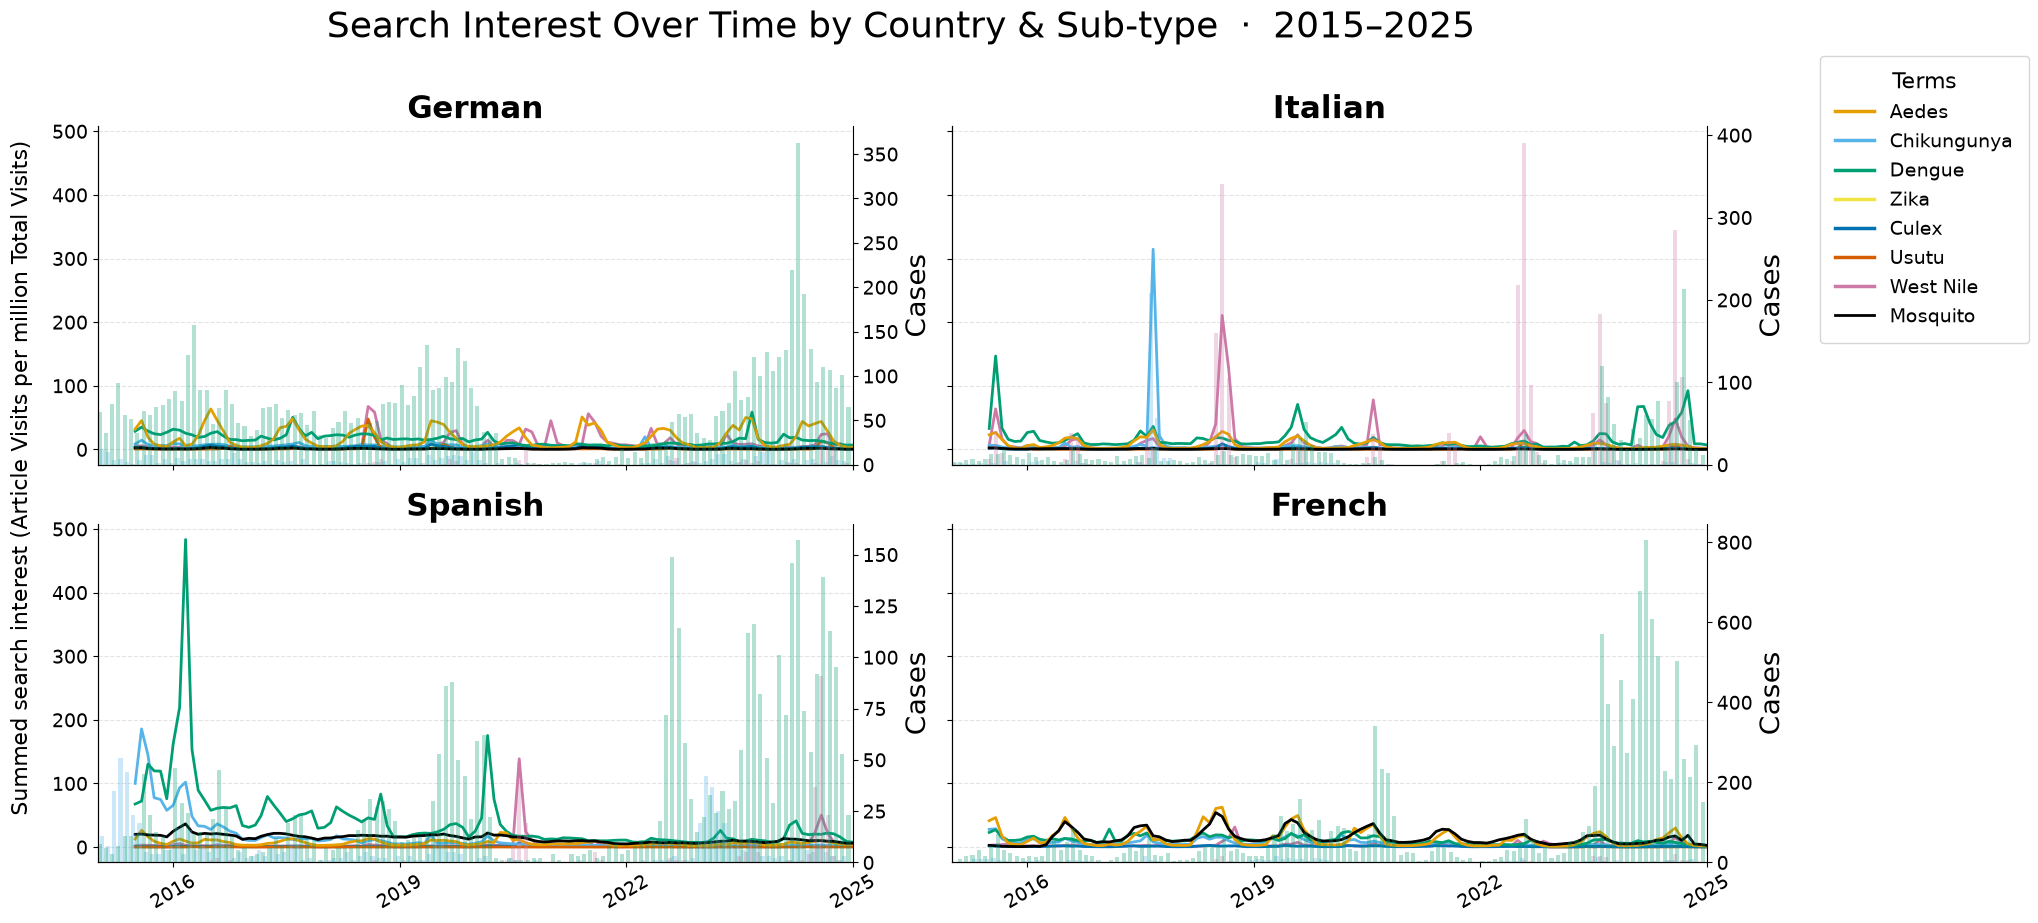

In [17]:
dengue = pd.read_csv(Path(CSV_PATH)/"ECDC_surveillance_data_Dengue.csv")
chik   = pd.read_csv(Path(CSV_PATH)/"ECDC_surveillance_data_Chikungunya_virus_disease.csv")
wnv    = pd.read_csv(Path(CSV_PATH)/"ECDC_surveillance_data_West_Nile_virus_infection.csv")
zika   = pd.read_csv(Path(CSV_PATH)/"ECDC_surveillance_data_Zika_virus_infection.csv")

def prep_ecdc(df):
    df = df.copy()
    df.columns = df.columns.str.lower().str.strip()

    # Convert Time (YYYY-MM) to datetime
    df["date"] = pd.to_datetime(df["time"], format="%Y-%m")

    # Clean numeric values
    df["numvalue"] = pd.to_numeric(df["numvalue"], errors="coerce").fillna(0)

    # Standardize names
    df = df.rename(columns={
        "regionname": "country",
        "numvalue": "cases"
    })

    return df[["country", "date", "cases"]]

dengue = prep_ecdc(dengue)
chik = prep_ecdc(chik)
wnv = prep_ecdc(wnv)
zika = prep_ecdc(zika)

# Build meta from qid_country_table (keyed by keyword as before)
meta = {
    row["Keyword"]: {"System": row["System"], "Sub-type": row["Sub-type"]}
    for _, row in qid_country_table.drop_duplicates(subset=["Keyword"]).iterrows()
}

# Build qid → keyword lookup
qid_to_keyword = qid_country_table.drop_duplicates(subset=["qid"]).set_index("qid")["Keyword"].to_dict()

# Build country_data: {country: DataFrame(date index, keyword columns)}
country_data: dict[str, pd.DataFrame] = {}

for geo in COUNTRY_ORDER:
    subset = pageviews[pageviews.index == geo].copy()
    if subset.empty:
        continue

    subset["date"] = pd.to_datetime(
        subset["year"].astype(str) + "-" + subset["month"].astype(str).str.zfill(2)
    )

    pivot = subset.pivot_table(index="date", columns="qid", values="views_norm", aggfunc="sum")

    # Replace QID column names with keywords
    pivot.columns = [qid_to_keyword.get(q, q) for q in pivot.columns]

    country_data[geo] = pivot

anchor_series: dict[str, pd.Series] = {}

for geo in COUNTRY_ORDER:
    subset = pageviews_anchor[pageviews_anchor.index == geo].copy()
    if subset.empty:
        print(f"WARNING: no anchor data found for {geo}")
        continue

    # Build a datetime index from year + month columns
    subset["date"] = pd.to_datetime(
        subset["year"].astype(str) + "-" + subset["month"].astype(str).str.zfill(2)
    )
    series = subset.set_index("date")["views_norm"].sort_index()
    anchor_series[geo] = series

    print(f"  {geo}: anchor loaded ({len(series)} points)")

def plot_timeseries(
    country_data: dict[str, pd.DataFrame],
    meta: dict[str, dict],
    anchor_series: dict[str, pd.Series] | None = None,
    save_path: Path | None = None,
) -> plt.Figure:

    subtype_to_system: dict[str, str] = {
        v["Sub-type"]: v["System"] for v in meta.values()
    }

    countries = [g for g in COUNTRY_ORDER if g in country_data]
    ncols, nrows = 2, 2

    fig, axes = plt.subplots(
        nrows, ncols,
        figsize=(18, 9),
        sharey=True,
        sharex=True,
    )
    axes_flat = axes.flatten()

    for ax, geo in zip(axes_flat, countries):

        df = country_data[geo]

        # 1. SEARCH INTEREST
        subtype_agg = {}

        for keyword in df.columns:
            if keyword not in meta:
                continue

            sub = meta[keyword]["Sub-type"]

            # 🚫 Skip Zika subtype
            if sub == "Zika":
                continue

            series = df[keyword].dropna()
            if series.empty:
                continue

            subtype_agg[sub] = subtype_agg.get(sub, pd.Series(dtype=float)).add(
                series, fill_value=0,
            )

        for sub, series in subtype_agg.items():
            colour = SUBTYPE_COLOURS.get(sub, "#888888")

            ax.plot(
                series.index,
                series.values,
                color=colour,
                linewidth=2,
                linestyle="solid",
                label=sub,
            )

        # 2. ANCHOR
        if anchor_series and geo in anchor_series:
            anc = anchor_series[geo]
            anchor_label = ANCHOR_PER_COUNTRY.get(geo, "anchor")

            ax.plot(
                anc.index,
                anc.values,
                color="black",
                linewidth=2,
                linestyle="solid",
                label=f"Anchor: {anchor_label}"
            )

        # 3. DISEASE DATA — MULTIPLE BAR SERIES (NO STACKING)
        all_disease_dfs = {
            "Chikungunya": chik,
            "West Nile": wnv,
            "Dengue": dengue,
            "Zika": zika,
            "Usutu": usutu if "usutu" in globals() else None,
        }

        disease_series = []
        for subtype, ddf in all_disease_dfs.items():
            if subtype == "Zika":
                continue

            if ddf is None:
                continue

            dsub = ddf[ddf["country"] == geo]
            if dsub.empty:
                continue

            mask = (dsub["date"] >= "2015-01-01") & (dsub["date"] <= "2025-01-01")
            dsub = dsub.loc[mask].copy()

            if dsub.empty:
                continue

            dsub["Subtype"] = subtype
            disease_series.append(dsub)

        if disease_series:
            ax2 = ax.twinx()

            offsets = np.linspace(-10, 10, len(disease_series))

            for offset, dsub in zip(offsets, disease_series):

                subtype = dsub["Subtype"].iloc[0]
                base_color = SUBTYPE_COLOURS.get(subtype, "grey")

                from matplotlib.colors import to_rgba
                pale = to_rgba(base_color, alpha=0.3)

                shifted_dates = dsub["date"] + pd.to_timedelta(offset, unit="D")

                ax2.bar(
                    shifted_dates,
                    dsub["cases"],
                    width=20,
                    color=pale,
                    label=f"{subtype} cases"
                )

            ax2.set_ylabel("Cases", fontsize=20)
            ax2.tick_params(axis="y", labelsize=14)
            ax2.spines["top"].set_visible(False)

        # 4. TITLES / STYLING
        ax.set_title(
            COUNTRY_LANGUAGES.get(geo, [geo])[0],
            fontsize=22,
            fontweight="bold",
            pad=6
        )

        ax.tick_params(axis="x", rotation=30, labelsize=14)
        ax.tick_params(axis="y", labelsize=14)
        ax.grid(axis="y", linestyle="--", alpha=0.35)
        ax.spines[["top", "right"]].set_visible(False)

        ax.set_xlim(pd.to_datetime("2015-01-01"), pd.to_datetime("2025-01-01"))

    axes_flat[0].xaxis.set_major_locator(mdates.YearLocator(3))
    axes_flat[0].xaxis.set_major_formatter(mdates.DateFormatter("%Y"))

    for ax in axes_flat[len(countries):]:
        ax.set_visible(False)

    fig.text(
        0.005, 0.5,
        "Summed search interest (Article Visits per million Total Visits)",
        va="center",
        rotation="vertical",
        fontsize=16
    )

    subtype_handles = [
        mlines.Line2D([], [], color=col, linewidth=2.5, label=st)
        for st, col in SUBTYPE_COLOURS.items()
        if st in subtype_to_system
    ]

    anchor_handle = [
        mlines.Line2D([], [], color="black", linewidth=2, linestyle="solid",
                      label="Mosquito")
    ]

    fig.legend(
        handles=subtype_handles + anchor_handle,
        title="Terms",
        title_fontsize=16,
        prop={'size': 14},
        loc="upper left",
        bbox_to_anchor=(1.005, 0.98),
        frameon=True,
        borderpad=0.8,
    )

    fig.suptitle(
        "Search Interest Over Time by Country & Sub-type  ·  2015–2025",
        fontsize=26,
        y=1.02,
    )

    plt.tight_layout(rect=[0.02, 0, 1, 1])

    if save_path:
        fig.savefig(save_path, dpi=150, bbox_inches="tight")
        print(f"Chart saved → {save_path}")

    return fig


fig = plot_timeseries(
    country_data,
    meta,
    anchor_series=anchor_series,
    save_path=OUTPUT_PATH / "WikiPageviews_without_zika.png",
)
plt.show()

2. Monthly plots per subtype

  Germany: anchor loaded (126 points)
  Italy: anchor loaded (126 points)
  Spain: anchor loaded (126 points)
  France: anchor loaded (126 points)


C:\Users\annab\AppData\Local\Temp\ipykernel_57044\1537309803.py:318: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0.03, 0, 0.90, 1])


Chart saved → C:\Users\annab\Documents\Work\2026_Senckenberg_Freelance\One_Health_Proposal_Eugenia\Wiki_pageviews\WikiPageviews_subtype_timeseries_Germany.png


C:\Users\annab\AppData\Local\Temp\ipykernel_57044\1537309803.py:318: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0.03, 0, 0.90, 1])


Chart saved → C:\Users\annab\Documents\Work\2026_Senckenberg_Freelance\One_Health_Proposal_Eugenia\Wiki_pageviews\WikiPageviews_subtype_timeseries_Italy.png


C:\Users\annab\AppData\Local\Temp\ipykernel_57044\1537309803.py:318: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0.03, 0, 0.90, 1])


Chart saved → C:\Users\annab\Documents\Work\2026_Senckenberg_Freelance\One_Health_Proposal_Eugenia\Wiki_pageviews\WikiPageviews_subtype_timeseries_Spain.png


C:\Users\annab\AppData\Local\Temp\ipykernel_57044\1537309803.py:318: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0.03, 0, 0.90, 1])


Chart saved → C:\Users\annab\Documents\Work\2026_Senckenberg_Freelance\One_Health_Proposal_Eugenia\Wiki_pageviews\WikiPageviews_subtype_timeseries_France.png
Zika chart saved → C:\Users\annab\Documents\Work\2026_Senckenberg_Freelance\One_Health_Proposal_Eugenia\Wiki_pageviews\WikiPageviews_zika_by_country.png


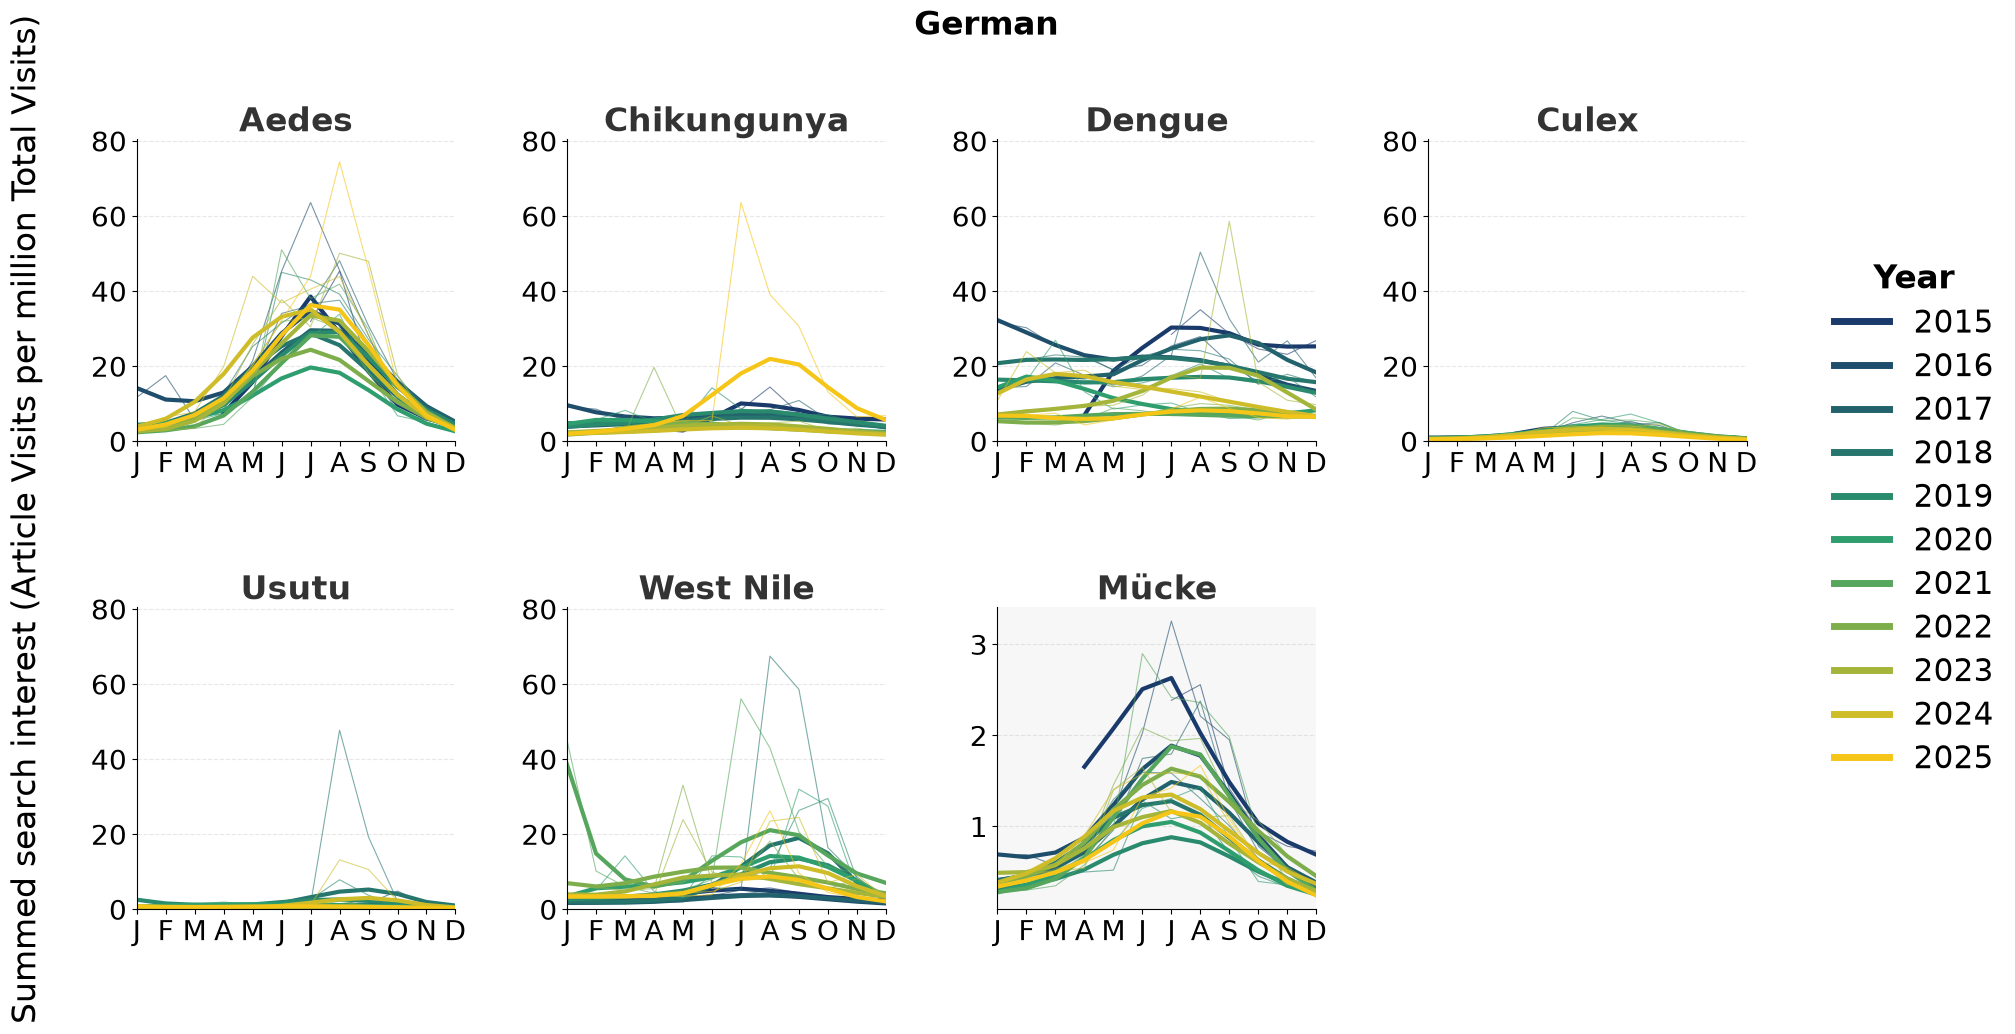

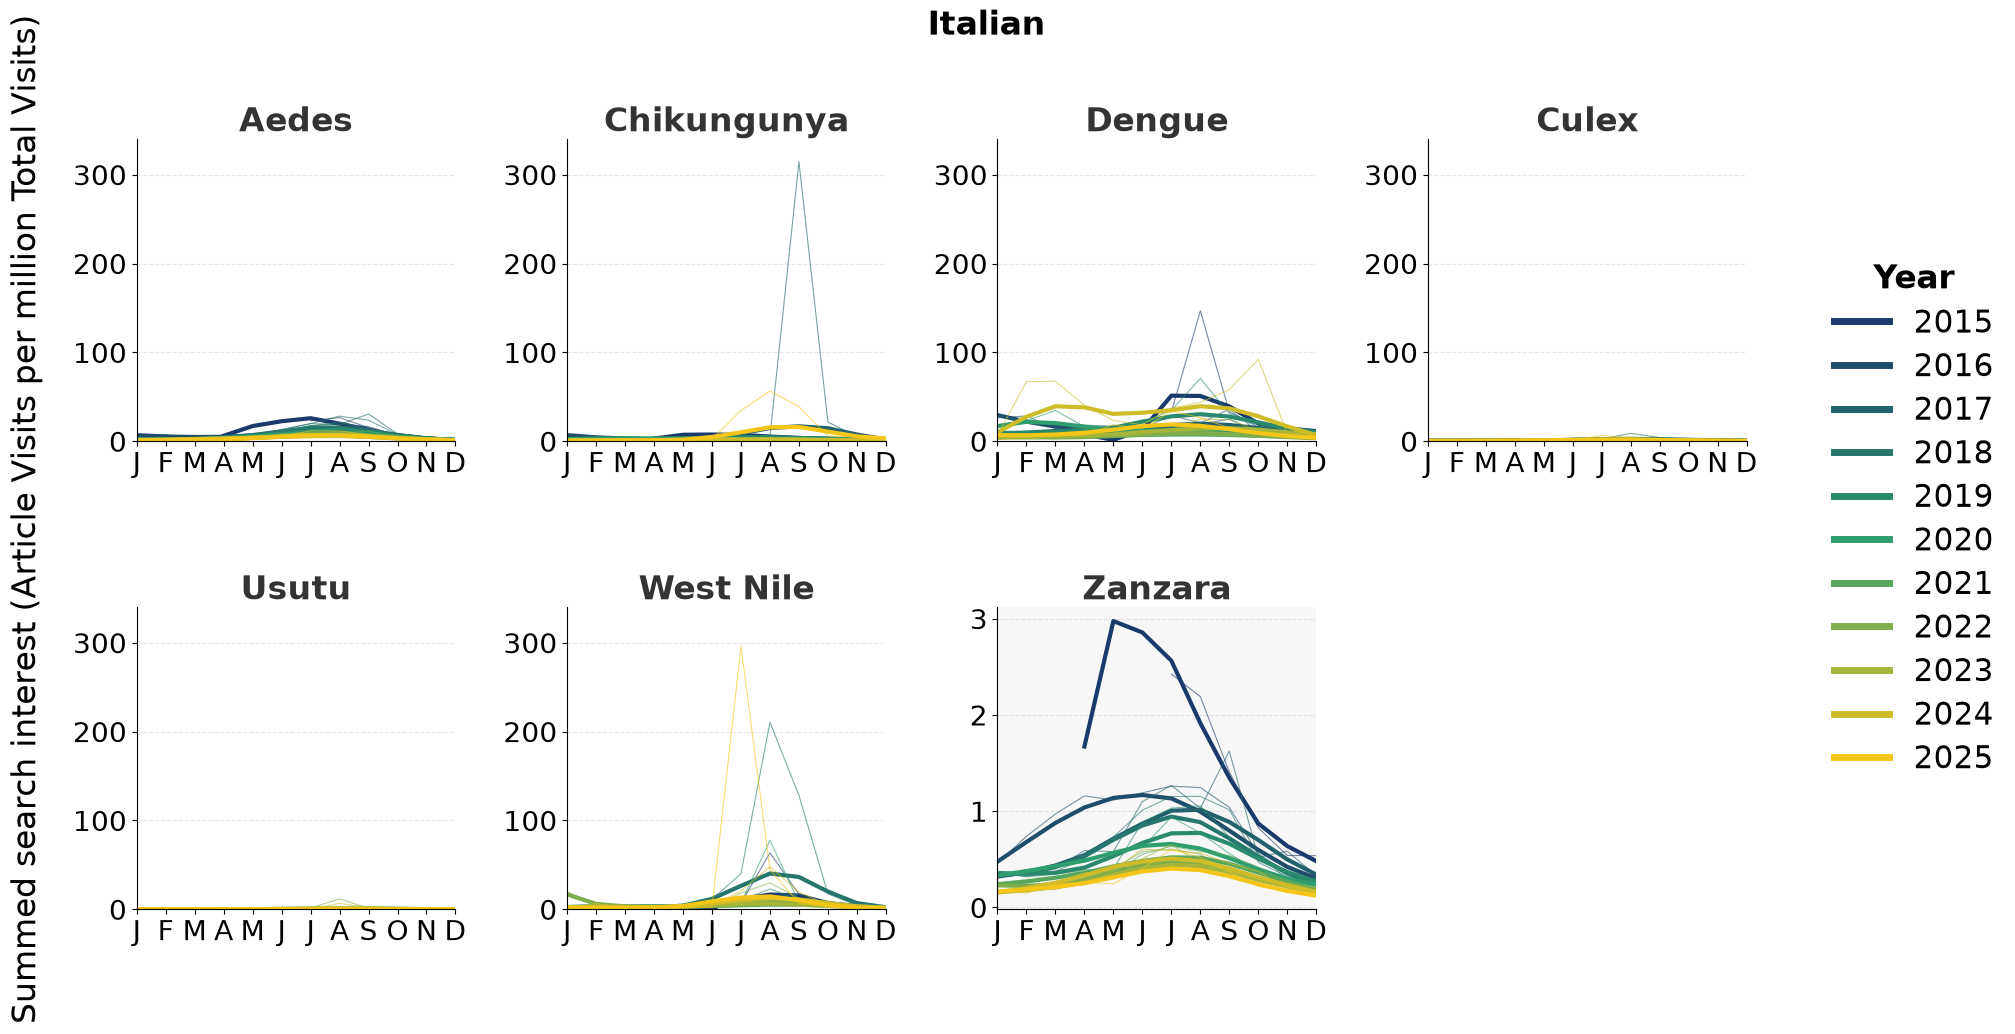

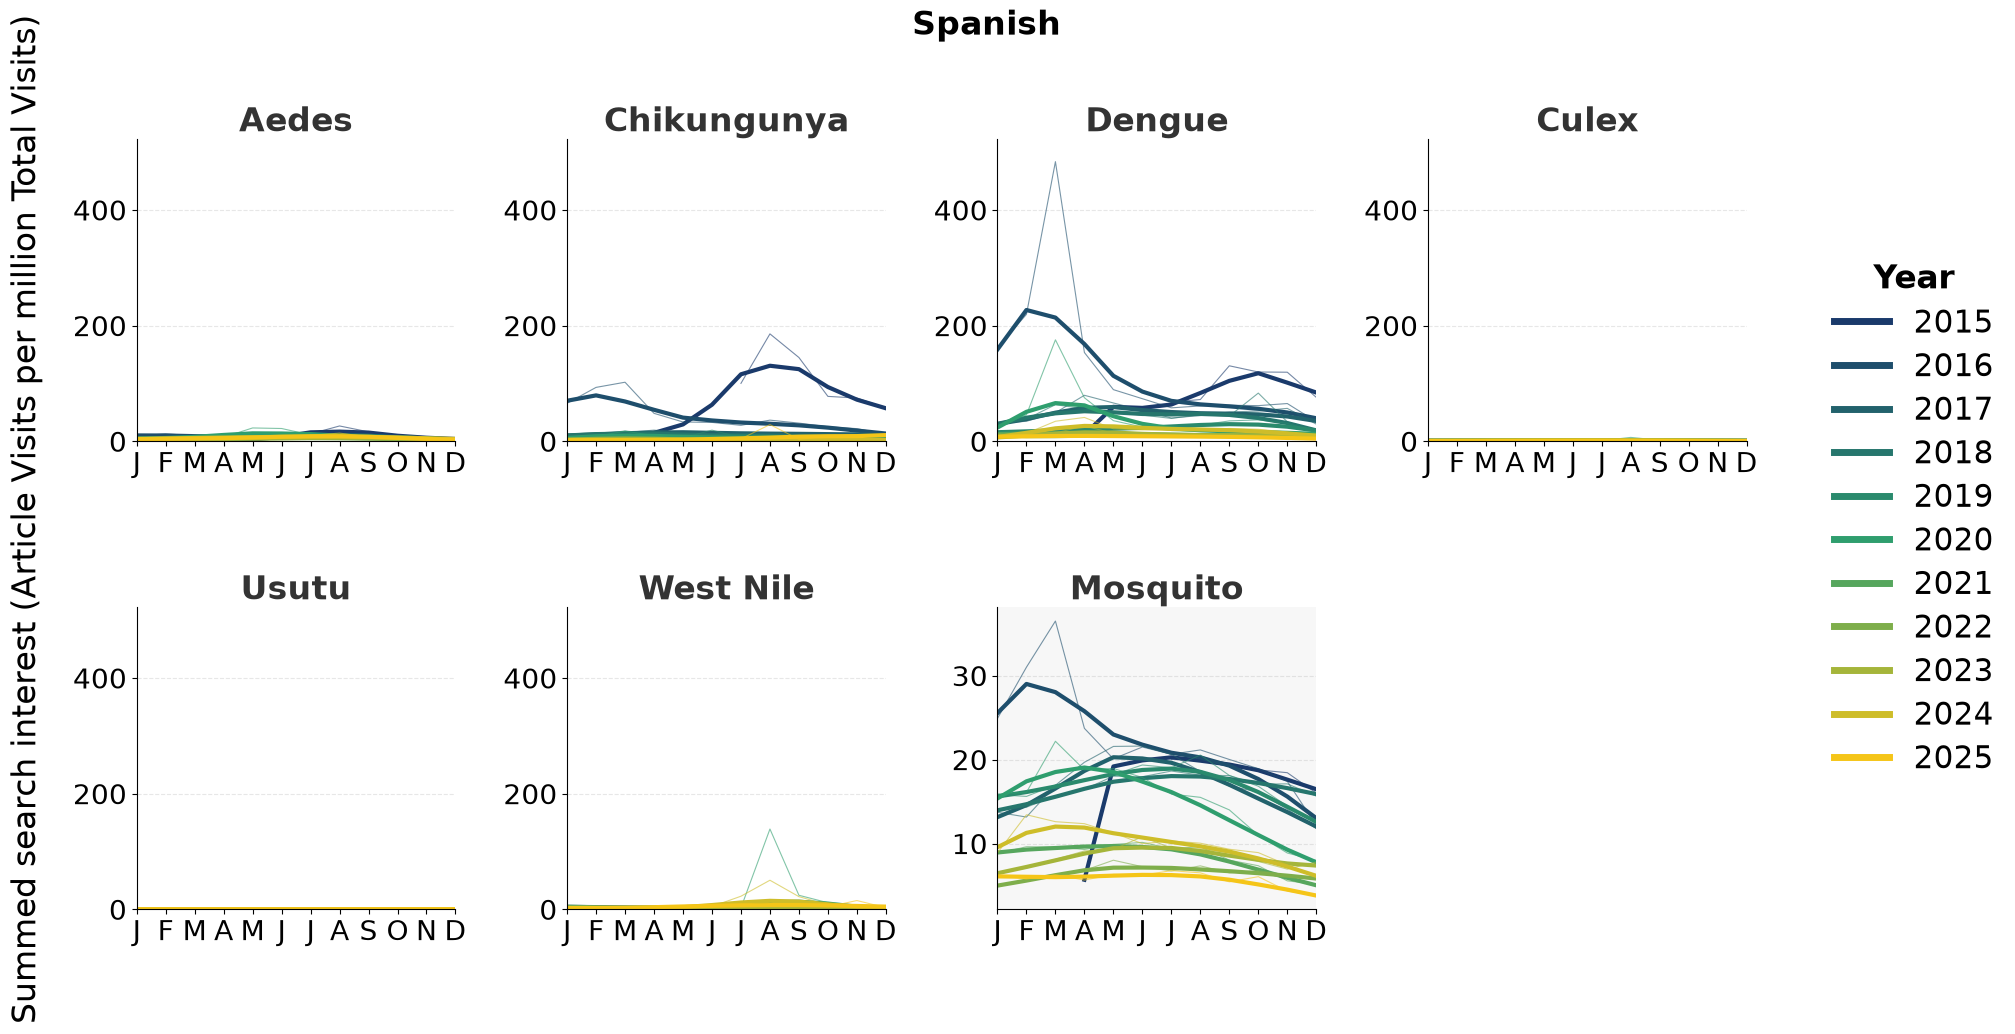

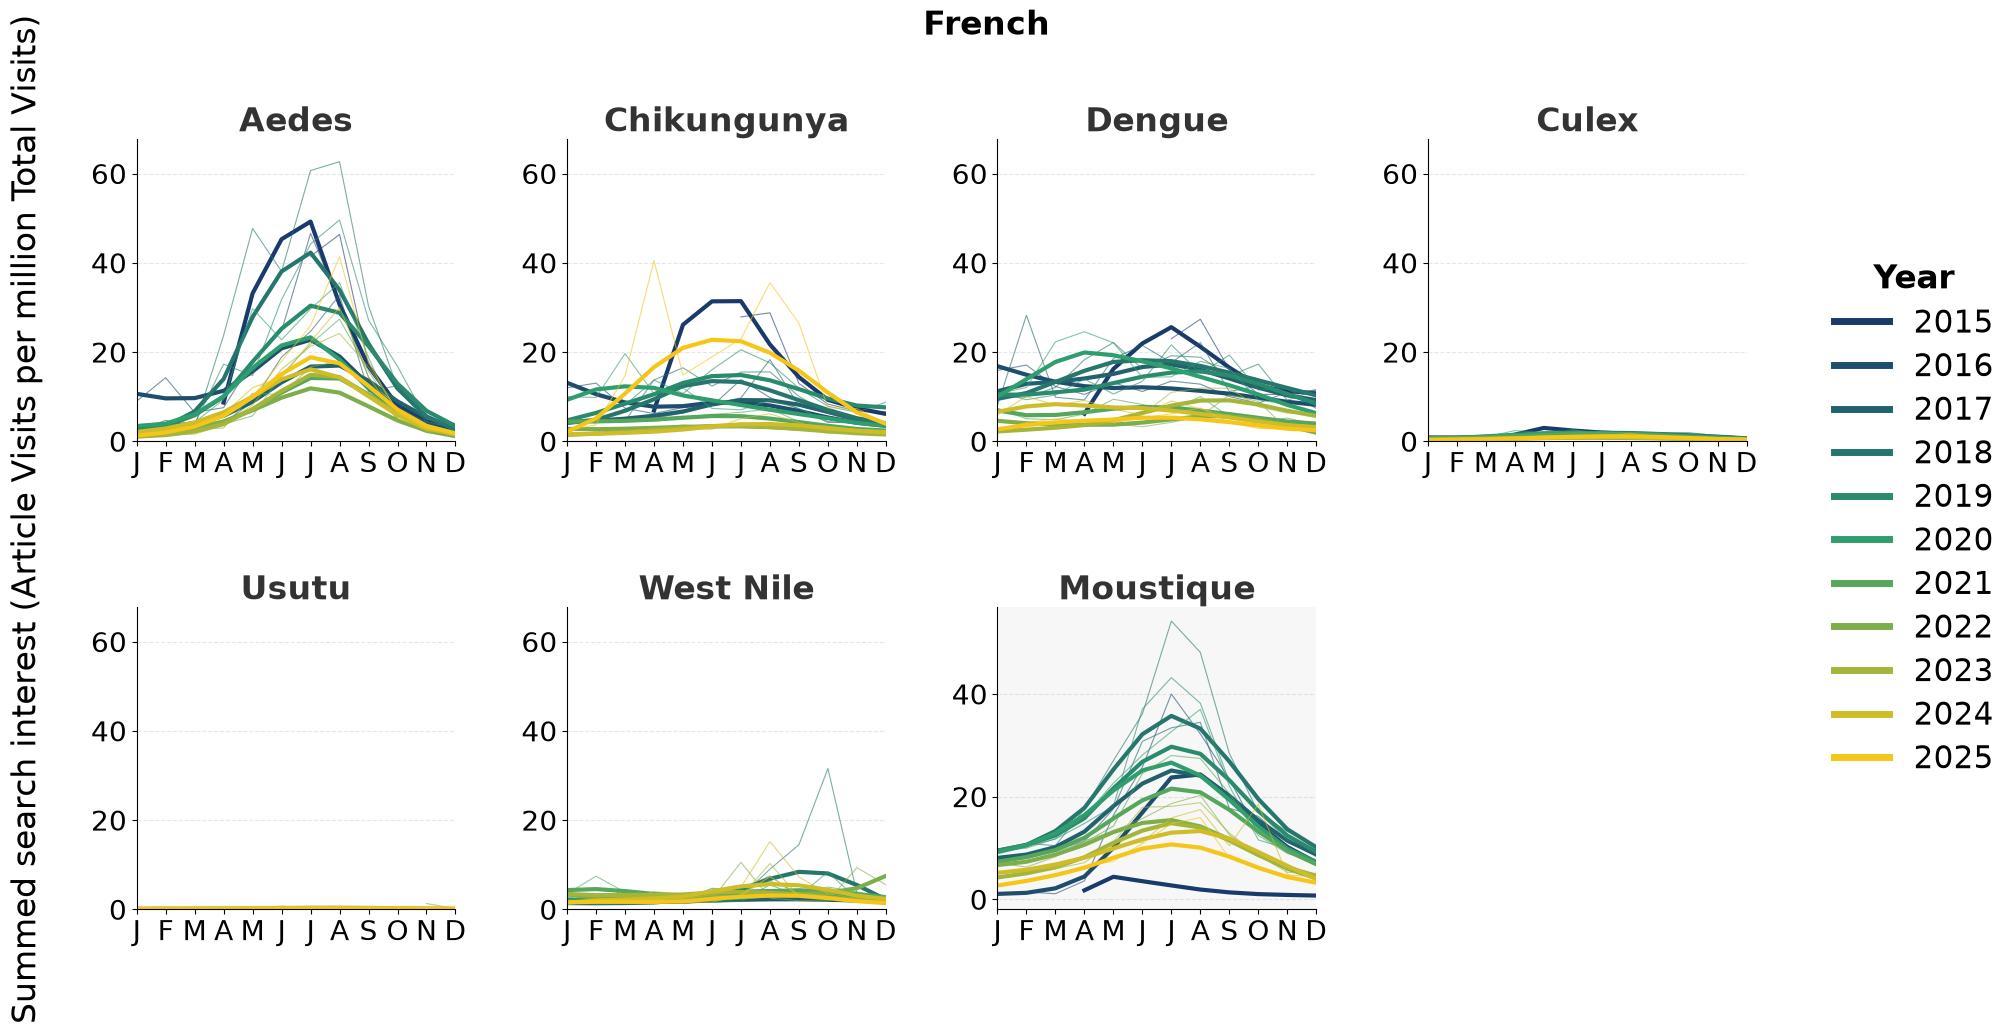

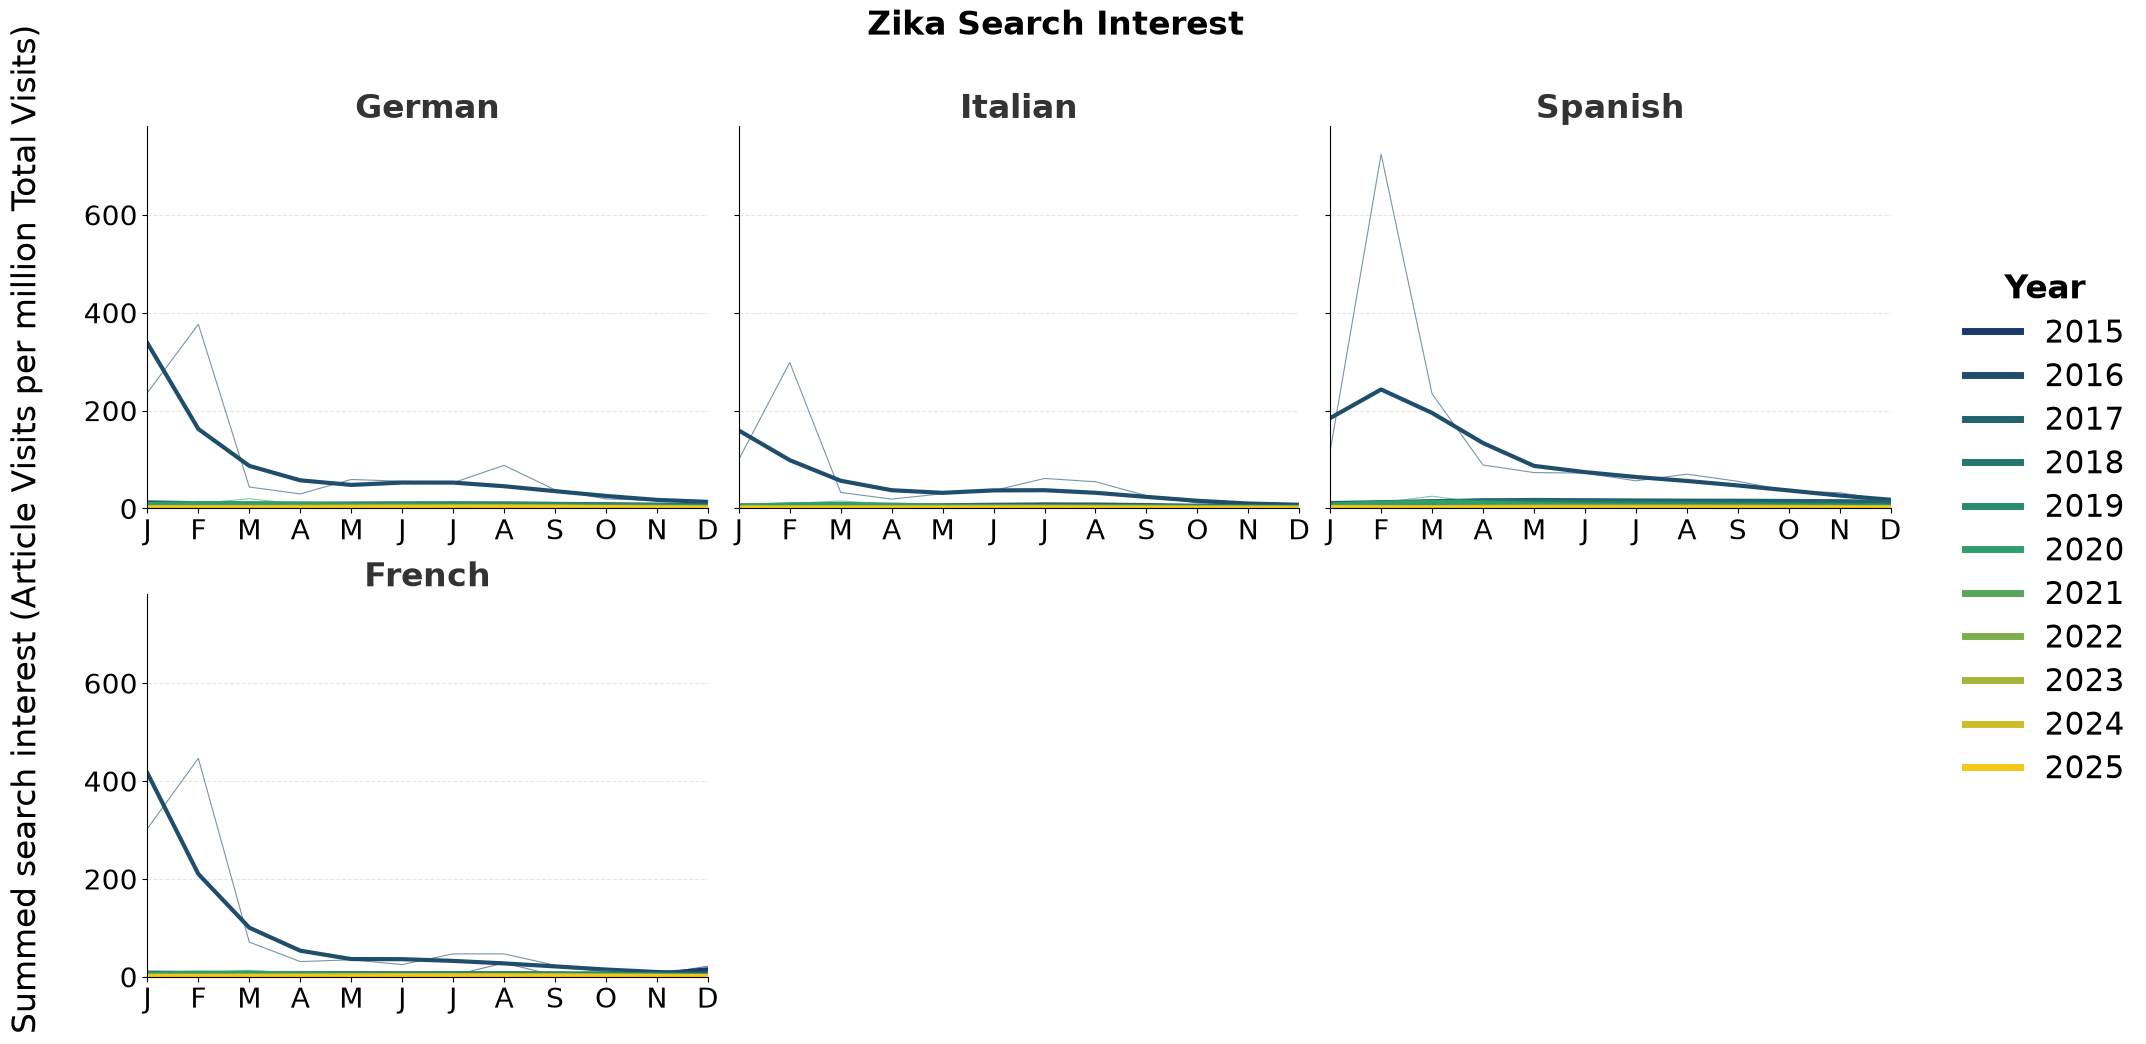

In [15]:
# ─────────────────────────────────────────────────────────────────────────────
# LOESS helper  (no statsmodels dependency — pure numpy)
# ─────────────────────────────────────────────────────────────────────────────
anchor_series: dict[str, pd.Series] = {}

for geo in COUNTRY_ORDER:
    subset = pageviews_anchor[pageviews_anchor.index == geo].copy()
    if subset.empty:
        print(f"WARNING: no anchor data found for {geo}")
        continue

    # Build a datetime index from year + month columns
    subset["date"] = pd.to_datetime(
        subset["year"].astype(str) + "-" + subset["month"].astype(str).str.zfill(2)
    )
    series = subset.set_index("date")["views_norm"].sort_index()
    anchor_series[geo] = series

    print(f"  {geo}: anchor loaded ({len(series)} points)")


def _loess(
    x: np.ndarray,
    y: np.ndarray,
    frac: float = 0.5,
    eps: float = 1e-6,
) -> np.ndarray:
    """
    Positivity-preserving LOESS.

    Fits the local regression on log(y + eps) and exponentiates the
    prediction, guaranteeing strictly positive fitted values.
    """
    n = len(x)
    out = np.full(n, np.nan)

    finite = np.isfinite(y)
    if finite.sum() < 3:
        return out

    half_window = max(int(np.ceil(frac * n / 2)), 2)

    for i in range(n):
        lo = max(0, i - half_window)
        hi = min(n, i + half_window)

        xi = x[lo:hi]
        yi = y[lo:hi]

        mask = np.isfinite(yi)
        if mask.sum() < 2:
            continue

        xi = xi[mask]
        yi = yi[mask]

        # ---- log transform ----
        log_y = np.log(np.maximum(yi, 0) + eps)

        # tricube weights
        d = np.abs(xi - x[i])
        max_d = d.max()
        if max_d == 0:
            max_d = 1.0

        w = (1 - (d / max_d) ** 3) ** 3

        # Weighted least squares without forming a diagonal matrix
        A = np.column_stack((np.ones_like(xi), xi))
        Aw = A * w[:, None]
        yw = log_y * w

        try:
            coef = np.linalg.lstsq(Aw, yw, rcond=None)[0]

            # predict on log scale
            pred_log = coef[0] + coef[1] * x[i]

            # back-transform to original scale
            out[i] = np.exp(pred_log)

        except np.linalg.LinAlgError:
            pass

    return out


# ─────────────────────────────────────────────────────────────────────────────
# CUSTOM 3-STOP COLORMAP  (dark-blue → green → yellow, colourblind-safe)
# ─────────────────────────────────────────────────────────────────────────────

_GRADIENT_COLOURS = [
    "#1a3a6b",   # dark navy-blue  (early years)
    "#2e9e6e",   # teal-green      (middle years)
    "#f5c518",   # warm yellow     (recent years)
]
YEAR_CMAP = mcolors.LinearSegmentedColormap.from_list(
    "blue_green_yellow", _GRADIENT_COLOURS
)


# ─────────────────────────────────────────────────────────────────────────────
# SHARED PANEL-DRAWING HELPER
# ─────────────────────────────────────────────────────────────────────────────

def _draw_series_panel(
    ax,
    series: pd.Series,
    year_colour: dict,
    loess_frac: float,
    y_lim: tuple | None = None,
    title: str = "",
    title_colour: str = "#333333",
    facecolor: str | None = None,
    month_labels: list | None = None,
):
    """Draw one sub-panel: faint raw lines + bold LOESS lines, one per year."""
    if month_labels is None:
        month_labels = ["J","F","M","A","M","J","J","A","S","O","N","D"]

    if facecolor:
        ax.set_facecolor(facecolor)

    for yr, yr_series in series.groupby(series.index.year):
        monthly = pd.Series(np.nan, index=range(1, 13), dtype=float)
        monthly.update(yr_series.set_axis(yr_series.index.month))
        colour = year_colour.get(yr, "grey")
        x_arr  = monthly.index.to_numpy(dtype=float)
        y_arr  = monthly.values.astype(float)

        ax.plot(x_arr, y_arr, color=colour, linewidth=0.8, alpha=0.6)
        smoothed = _loess(x_arr, y_arr, frac=loess_frac)
        ax.plot(x_arr, smoothed, color=colour, linewidth=3.0, alpha=1)

    ax.set_title(title, fontsize=24, fontweight="bold", color=title_colour, pad=4)
    ax.set_xticks(range(1, 13))
    ax.set_xticklabels(month_labels, fontsize=20, ha="center")
    ax.set_xlim(1, 12)
    ax.tick_params(axis="y", labelsize=20)
    ax.margins(x=0)
    if y_lim:
        ax.set_ylim(*y_lim)
    ax.grid(axis="y", linestyle="--", alpha=0.3)
    ax.spines[["top", "right"]].set_visible(False)


def _add_year_legend(fig, norm, years_sorted, right_x=0.91):
    handles = [
        mlines.Line2D([], [], color=YEAR_CMAP(norm(yr)), linewidth=5, label=str(yr))
        for yr in years_sorted
    ]
    leg = fig.legend(
        handles=handles,
        title="Year",
        title_fontsize=24,
        fontsize=22,
        loc="center left",
        bbox_to_anchor=(right_x, 0.5),
        frameon=False,
        handlelength=1.8,
        handleheight=0.8,
        labelspacing=0.4,
    )
    leg.get_title().set_fontweight("bold")


# ─────────────────────────────────────────────────────────────────────────────
# BUILD subtype_means: {date: {geo::subtype: views_norm}}
# (replaces the country_data dict used in the original code)
# ─────────────────────────────────────────────────────────────────────────────

# 1. Attach keyword + sub-type to pageviews via qid
pv = pageviews.reset_index()  # brings 'country' back as a column if it was the index
pv = pv.rename(columns={"index": "country"}) if "country" not in pv.columns else pv

pv = pv.merge(
    qid_country_table[["qid", "Keyword", "Sub-type"]].drop_duplicates(subset=["qid"]),
    on="qid",
    how="left",
)

pv["date"] = pd.to_datetime(
    pv["year"].astype(str) + "-" + pv["month"].astype(str).str.zfill(2)
)

# 2. Aggregate to (date, country, Sub-type) — sum across keywords within same sub-type
agg = (
    pv.groupby(["date", "country", "Sub-type"])["views_norm"]
    .sum()
    .reset_index()
)

# 3. Pivot to wide format with columns "country::Sub-type"
agg["col"] = agg["country"] + "::" + agg["Sub-type"]
subtype_means = agg.pivot_table(index="date", columns="col", values="views_norm", aggfunc="sum")
subtype_means.index = pd.to_datetime(subtype_means.index)

# Rebuild meta keyed by Sub-type (used for zika detection etc.)
meta = {
    row["Sub-type"]: {"System": row["System"], "Sub-type": row["Sub-type"]}
    for _, row in qid_country_table.drop_duplicates(subset=["Sub-type"]).iterrows()
}


# ─────────────────────────────────────────────────────────────────────────────
# COUNTRY FIGURES  (Zika excluded)
# ─────────────────────────────────────────────────────────────────────────────

def plot_timeseries(
    df: pd.DataFrame,
    meta: dict,
    anchor_series: dict | None = None,
    save_path: Path | None = None,
    loess_frac: float = 0.7,
    zika_subtype: str = "Zika",
) -> list[plt.Figure]:
    """
    One figure per country, 4×2 grid of sub-panels.
    Each panel = one sub-type; lines are coloured by year (blue→green→yellow).
    Zika excluded here; use plot_zika_figure() for Zika.
    Anchor panel shown in last slot with grey background.
    """
    MONTH_LABELS = ["J","F","M","A","M","J","J","A","S","O","N","D"]
    N_COLS, N_ROWS = 4, 2
    MAX_PANELS = N_COLS * N_ROWS

    df = df.copy()
    df.index = pd.to_datetime(df.index)

    col_tuples   = [c.split("::") for c in df.columns]
    all_geos     = list(dict.fromkeys(t[0] for t in col_tuples))
    all_subtypes = list(dict.fromkeys(t[1] for t in col_tuples))

    countries = [g for g in COUNTRY_ORDER if g in all_geos] or all_geos

    subtypes_order = [s for s in SUBTYPE_COLOURS if s in all_subtypes]
    subtypes_order += [s for s in all_subtypes if s not in subtypes_order]
    subtypes_order = [s for s in subtypes_order if s != zika_subtype]

    years_sorted = sorted(df.index.year.unique())
    year_min, year_max = years_sorted[0], years_sorted[-1]
    norm        = mcolors.Normalize(vmin=year_min, vmax=year_max)
    year_colour = {yr: YEAR_CMAP(norm(yr)) for yr in years_sorted}

    figures = []

    for geo in countries:
        geo_cols = {t[1]: f"{geo}::{t[1]}" for t in col_tuples if t[0] == geo}
        subtypes_present = [s for s in subtypes_order if s in geo_cols]

        has_anchor = anchor_series is not None and geo in anchor_series
        n_subtype_slots = MAX_PANELS - (1 if has_anchor else 0)
        subtypes_show = subtypes_present[:n_subtype_slots]

        panel_list = subtypes_show[:]
        if has_anchor:
            panel_list.append("__anchor__")
        panel_list += [None] * (MAX_PANELS - len(panel_list))

        country_label = COUNTRY_LANGUAGES.get(geo, [geo])[0]

        fig = plt.figure(figsize=(20, 10))
        fig.suptitle(country_label, fontsize=24, fontweight="bold", y=1.01)

        outer = gridspec.GridSpec(
            N_ROWS, N_COLS, figure=fig,
            hspace=0.55, wspace=0.35, right=0.88, left=0.075,
        )

        # Shared y-range across non-Zika sub-types for this country
        non_zika_cols = [
            c for c in df.columns
            if c.startswith(f"{geo}::") and not c.endswith(f"::{zika_subtype}")
        ]
        country_vals = df[non_zika_cols] if non_zika_cols else df[
            [c for c in df.columns if c.startswith(f"{geo}::")]
        ]
        y_max = np.nanmax(country_vals.values)
        y_pad = y_max * 0.08 or 1
        y_lim = (0, y_max + y_pad)

        for idx, panel in enumerate(panel_list):
            row, col = divmod(idx, N_COLS)
            ax = fig.add_subplot(outer[row, col])

            if panel is None:
                ax.set_visible(False)
                continue

            if panel == "__anchor__":
                anc = anchor_series[geo].copy()
                anc.index = pd.to_datetime(anc.index)
                country_label = COUNTRY_LABELS.get(geo, geo)
                anchor_word = ANCHOR_PER_COUNTRY.get(country_label, "anchor")
                _draw_series_panel(
                    ax, anc, year_colour, loess_frac,
                    y_lim=None,
                    title=f"{anchor_word}",
                    facecolor="#f7f7f7",
                    month_labels=MONTH_LABELS,
                )
                continue

            series = df[geo_cols[panel]]
            _draw_series_panel(
                ax, series, year_colour, loess_frac,
                y_lim=y_lim,
                title=panel,
                month_labels=MONTH_LABELS,
            )

        fig.supylabel(
            "Summed search interest (Article Visits per million Total Visits)",
            fontsize=24, ha="center",
        )

        _add_year_legend(fig, norm, years_sorted)
        plt.tight_layout(rect=[0.03, 0, 0.90, 1])

        if save_path:
            out = save_path.parent / f"{save_path.stem}_{geo}{save_path.suffix}"
            fig.savefig(out, dpi=150, bbox_inches="tight")
            print(f"Chart saved → {out}")

        figures.append(fig)

    return figures


# ─────────────────────────────────────────────────────────────────────────────
# ZIKA FIGURE  (one panel per country, all on one figure)
# ─────────────────────────────────────────────────────────────────────────────

def plot_zika_figure(
    df: pd.DataFrame,
    meta: dict | None = None,
    save_path: Path | None = None,
    loess_frac: float = 0.7,
    zika_subtype: str = "Zika",
) -> plt.Figure:
    """
    Single figure with one panel per country showing Zika search interest.
    Layout: up to 3 columns, rows as needed.
    Lines = years (same blue→green→yellow gradient as the country figures).
    """
    MONTH_LABELS = ["J","F","M","A","M","J","J","A","S","O","N","D"]

    df = df.copy()
    df.index = pd.to_datetime(df.index)

    col_tuples = [c.split("::") for c in df.columns]
    all_geos   = list(dict.fromkeys(t[0] for t in col_tuples))

    countries = [g for g in COUNTRY_ORDER if g in all_geos] or all_geos

    zika_cols = {
        geo: f"{geo}::{zika_subtype}"
        for geo in countries
        if f"{geo}::{zika_subtype}" in df.columns
    }
    countries_with_zika = [g for g in countries if g in zika_cols]

    if not countries_with_zika:
        print("[warn] No Zika columns found in DataFrame.")
        return plt.figure()

    years_sorted = sorted(df.index.year.unique())
    year_min, year_max = years_sorted[0], years_sorted[-1]
    norm        = mcolors.Normalize(vmin=year_min, vmax=year_max)
    year_colour = {yr: YEAR_CMAP(norm(yr)) for yr in years_sorted}

    n     = len(countries_with_zika)
    ncols = min(3, n)
    nrows = int(np.ceil(n / ncols))

    fig, axes = plt.subplots(
        nrows, ncols,
        figsize=(7 * ncols, 5 * nrows),
        sharey=True,
        squeeze=False,
    )
    axes_flat = axes.flatten()

    zika_values = df[[v for v in zika_cols.values()]].values
    y_max = np.nanmax(zika_values)
    y_pad = y_max * 0.08 or 1
    y_lim = (0, y_max + y_pad)

    for i, geo in enumerate(countries_with_zika):
        ax = axes_flat[i]
        series = df[zika_cols[geo]]
        country_label = COUNTRY_LANGUAGES.get(geo, [geo])[0]

        _draw_series_panel(
            ax, series, year_colour, loess_frac,
            y_lim=y_lim,
            title=country_label,
            month_labels=MONTH_LABELS,
        )

    for ax in axes_flat[len(countries_with_zika):]:
        ax.set_visible(False)

    fig.suptitle("Zika Search Interest", fontsize=24, fontweight="bold", y=1.02)
    fig.text(
        0.01, 0.5,
        "Summed search interest (Article Visits per million Total Visits)",
        va="center", ha="center",
        rotation="vertical", fontsize=24,
    )

    _add_year_legend(fig, norm, years_sorted, right_x=0.92)
    plt.tight_layout(rect=[0.03, 0, 0.91, 1])

    if save_path:
        fig.savefig(save_path, dpi=150, bbox_inches="tight")
        print(f"Zika chart saved → {save_path}")

    return fig


# ─────────────────────────────────────────────────────────────────────────────
# USAGE
# ─────────────────────────────────────────────────────────────────────────────

figs = plot_timeseries(
    subtype_means, meta,
    anchor_series=anchor_series,
    save_path=OUTPUT_PATH / "WikiPageviews_subtype_timeseries.png",
)

fig_zika = plot_zika_figure(
    subtype_means, meta,
    save_path=OUTPUT_PATH / "WikiPageviews_zika_by_country.png",
)

plt.show()

Optional: Per_country deep dive plots

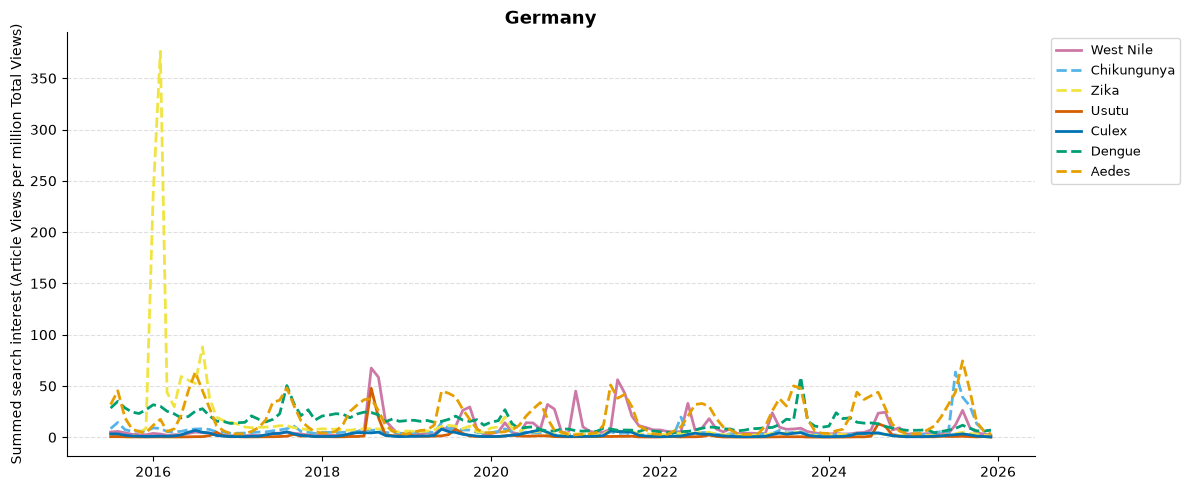

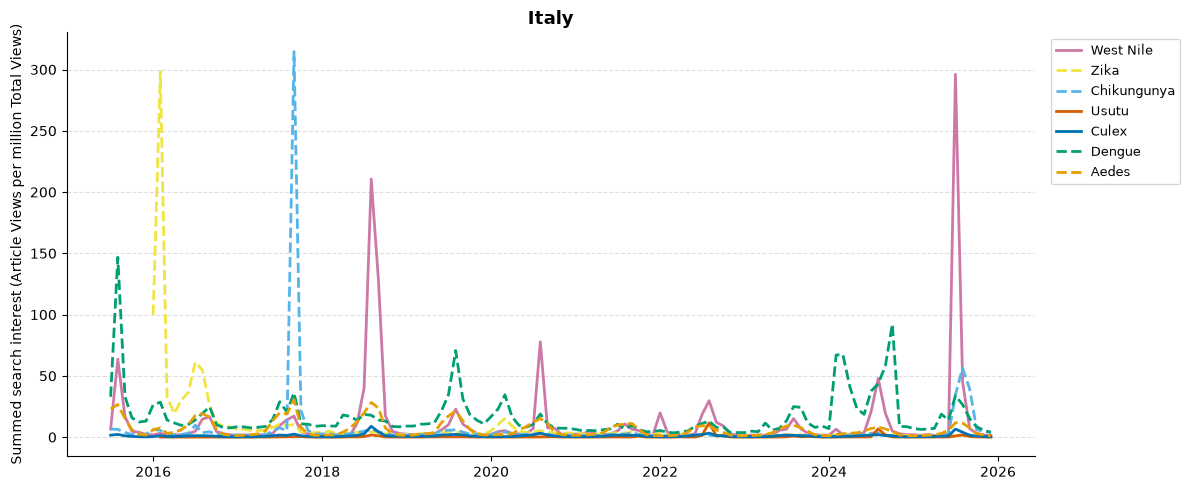

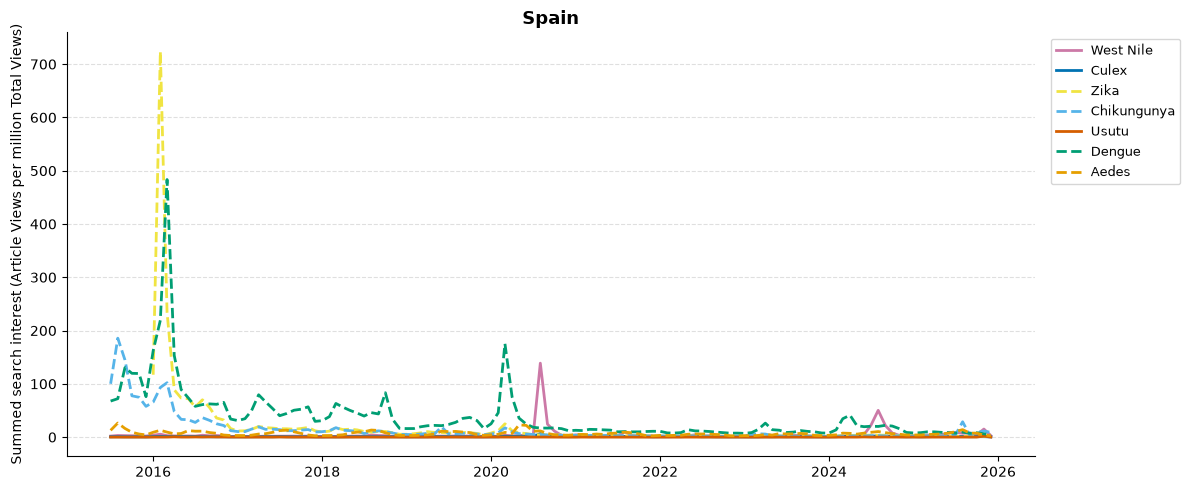

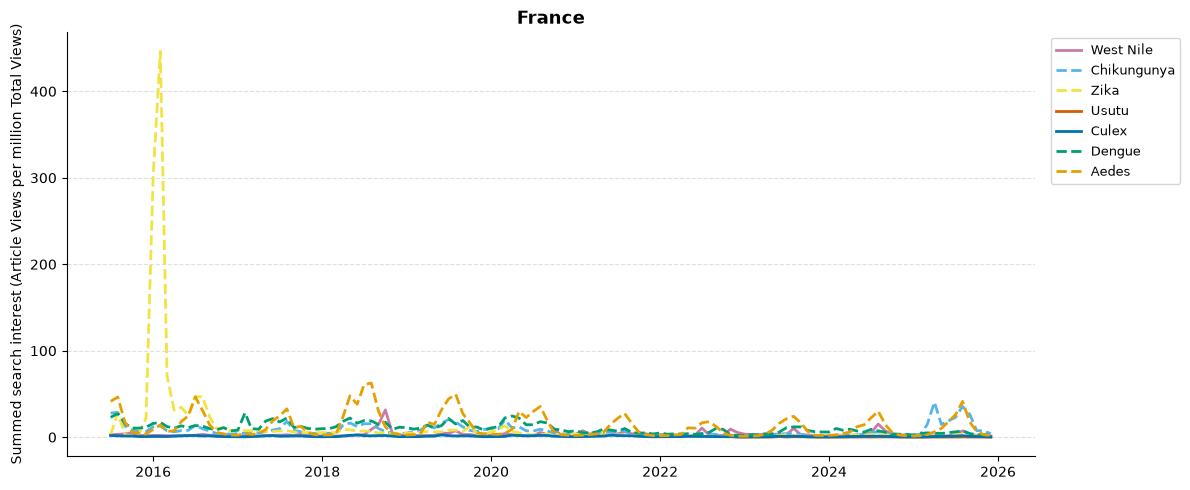

In [8]:
for geo in COUNTRY_ORDER:
    if geo not in country_data:
        continue

    # Aggregate series by sub-type (sum all keywords that share a sub-type)
    subtype_series = {}
    for keyword, series in country_data[geo].items():
        if keyword not in meta:
            continue  # skip anything not defined in meta
        sub = meta[keyword]["Sub-type"]
        if sub in subtype_series:
            subtype_series[sub] = subtype_series[sub].add(series, fill_value=0)
        else:
            subtype_series[sub] = series.copy()

    fig_c, ax = plt.subplots(figsize=(12, 5))
    for sub, series in subtype_series.items():
        colour    = SUBTYPE_COLOURS.get(sub, "#888888")
        system    = meta[next(k for k in meta if meta[k]["Sub-type"] == sub)]["System"]
        linestyle = SYSTEM_STYLES.get(system, "solid")
        ax.plot(series.index, series.values,
                color=colour, linewidth=2, linestyle=linestyle, label=sub)

    ax.set_title(f"{COUNTRY_LABELS.get(geo, geo)}", fontsize=13, fontweight="bold")
    ax.set_ylabel("Summed search interest (Article Views per million Total Views)")
    ax.legend(fontsize=9, bbox_to_anchor=(1.01, 1), loc="upper left")
    ax.xaxis.set_major_locator(mdates.YearLocator(2))
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
    ax.grid(axis="y", linestyle="--", alpha=0.4)
    ax.spines[["top", "right"]].set_visible(False)
    plt.tight_layout()
    fig_c.savefig(OUTPUT_PATH / f"trends_{geo}.png", dpi=150, bbox_inches="tight")
    plt.show()

Per system

  Germany: anchor loaded (126 points)
  Italy: anchor loaded (126 points)
  Spain: anchor loaded (126 points)
  France: anchor loaded (126 points)
Chart saved → C:\Users\annab\Documents\Work\2026_Senckenberg_Freelance\One_Health_Proposal_Eugenia\Wiki_pageviews\trends_timeseries_system.png


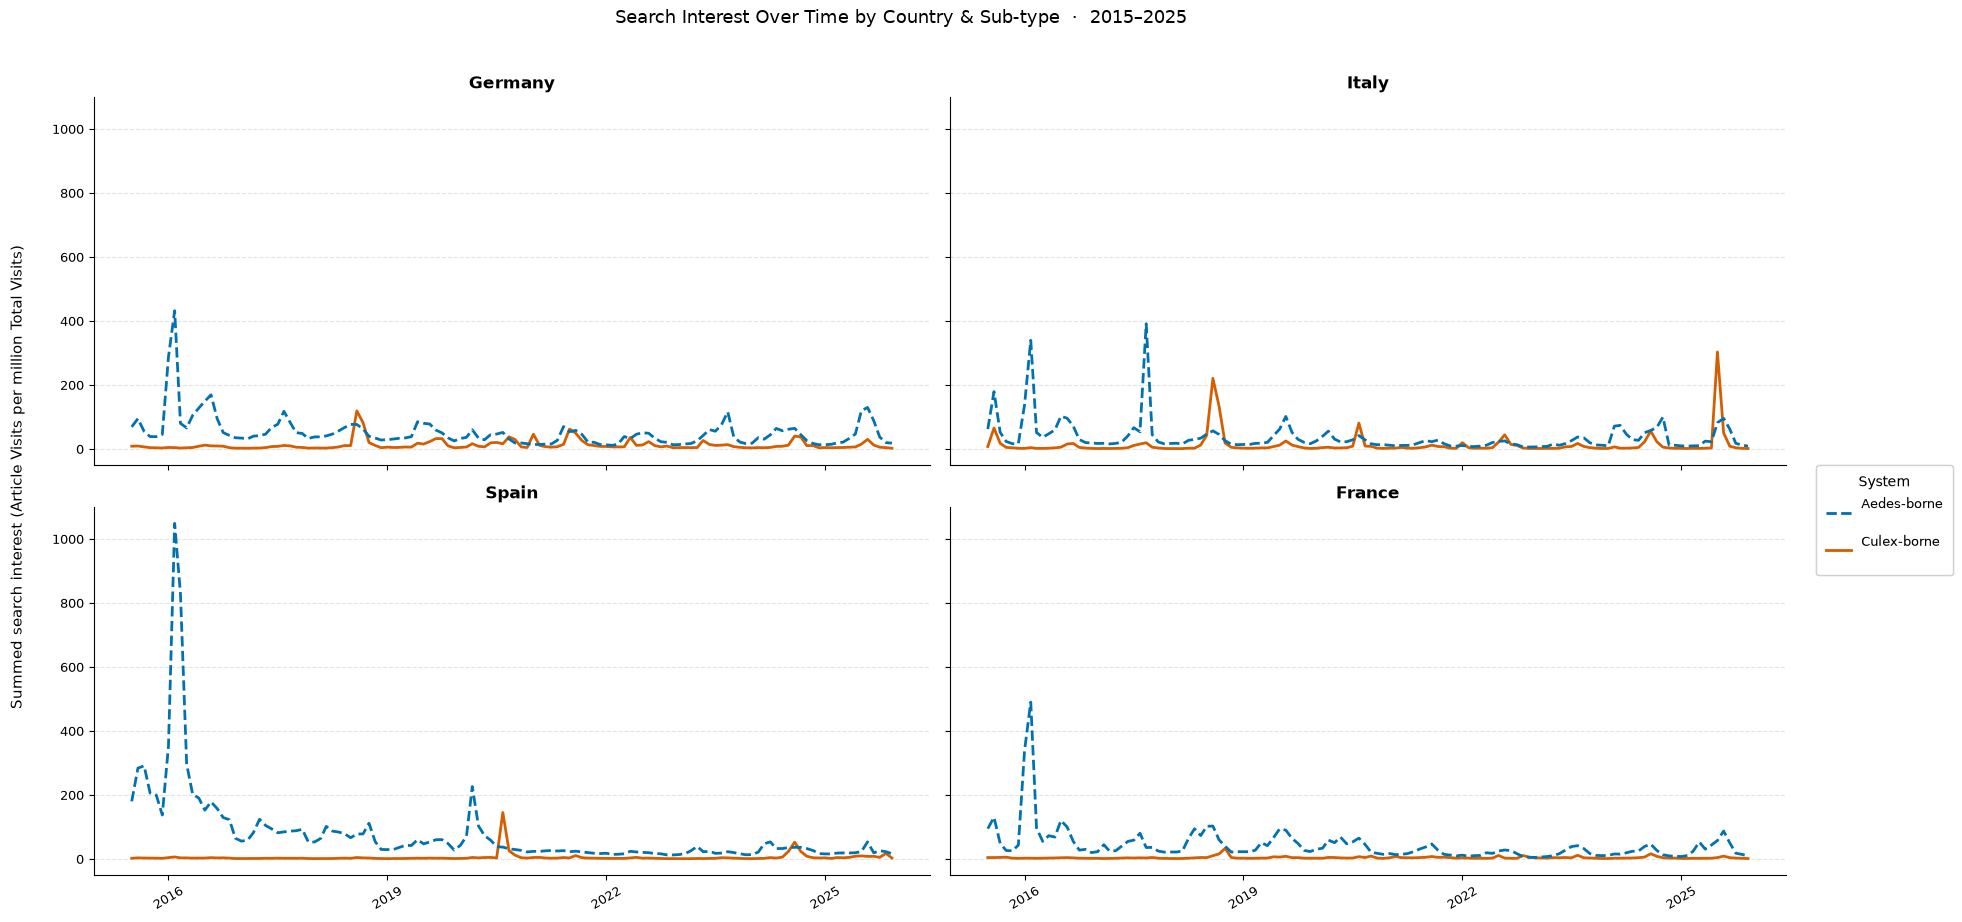

In [16]:
# Build meta from qid_country_table (keyed by keyword as before)
meta = {
    row["Keyword"]: {"System": row["System"], "Sub-type": row["Sub-type"]}
    for _, row in qid_country_table.drop_duplicates(subset=["Keyword"]).iterrows()
}

# Build qid → keyword lookup
qid_to_keyword = qid_country_table.drop_duplicates(subset=["qid"]).set_index("qid")["Keyword"].to_dict()

# Build country_data: {country: DataFrame(date index, keyword columns)}
country_data: dict[str, pd.DataFrame] = {}

for geo in COUNTRY_ORDER:
    subset = pageviews[pageviews.index == geo].copy()
    if subset.empty:
        continue

    subset["date"] = pd.to_datetime(
        subset["year"].astype(str) + "-" + subset["month"].astype(str).str.zfill(2)
    )

    pivot = subset.pivot_table(index="date", columns="qid", values="views_norm", aggfunc="sum")

    # Replace QID column names with keywords
    pivot.columns = [qid_to_keyword.get(q, q) for q in pivot.columns]

    country_data[geo] = pivot

anchor_series: dict[str, pd.Series] = {}

for geo in COUNTRY_ORDER:
    subset = pageviews_anchor[pageviews_anchor.index == geo].copy()
    if subset.empty:
        print(f"WARNING: no anchor data found for {geo}")
        continue

    # Build a datetime index from year + month columns
    subset["date"] = pd.to_datetime(
        subset["year"].astype(str) + "-" + subset["month"].astype(str).str.zfill(2)
    )
    series = subset.set_index("date")["views_norm"].sort_index()
    anchor_series[geo] = series

    print(f"  {geo}: anchor loaded ({len(series)} points)")

def plot_timeseries(
    country_data: dict[str, pd.DataFrame],
    meta: dict[str, dict],
    anchor_series: dict[str, pd.Series] | None = None,
    save_path: Path | None = None,
) -> plt.Figure:

    subtype_to_system: dict[str, str] = {
        v["Sub-type"]: v["System"] for v in meta.values()
    }

    countries = [g for g in COUNTRY_ORDER if g in country_data]
    ncols, nrows = 2, 2

    fig, axes = plt.subplots(
        nrows, ncols,
        figsize=(18, 9),
        sharey=True,
        sharex=True,
    )
    axes_flat = axes.flatten()

    for ax, geo in zip(axes_flat, countries):
        df = country_data[geo]

        # Aggregate raw keywords → one series per sub-type
        system_agg: dict[str, pd.Series] = {}
        for keyword in df.columns:
            if keyword not in meta:
                continue
            sub = meta[keyword]["System"]
            series = df[keyword].dropna()
            if series.empty:
                continue
            if sub in system_agg:
                system_agg[sub] = system_agg[sub].add(series, fill_value=0)
            else:
                system_agg[sub] = series.copy()

        # Now plot one line per sub-type
        for sub, series in system_agg.items():
            colour    = SYSTEM_COLOURS.get(sub, "#888888")
            linestyle = SYSTEM_STYLES.get(sub, "solid")
            ax.plot(series.index, series.values,
                    color=colour, linewidth=2, linestyle=linestyle, label=sub)

        #if anchor_series and geo in anchor_series:
         #   anc = anchor_series[geo]
          #  anchor_label = ANCHOR_PER_COUNTRY.get(geo, "anchor")
           # ax.plot(anc.index, anc.values,
            #        color="black", linewidth=2,
             #       linestyle="solid", label=f"Anchor: {anchor_label}")

        ax.set_title(COUNTRY_LABELS.get(geo, geo),
                     fontsize=12, fontweight="bold", pad=6)
        ax.tick_params(axis="x", rotation=30, labelsize=9)
        ax.tick_params(axis="y", labelsize=9)
        ax.grid(axis="y", linestyle="--", alpha=0.35)
        ax.spines[["top", "right"]].set_visible(False)

    axes_flat[0].xaxis.set_major_locator(mdates.YearLocator(3))
    axes_flat[0].xaxis.set_major_formatter(mdates.DateFormatter("%Y"))

    for ax in axes_flat[len(countries):]:
        ax.set_visible(False)

    # Shared y-label
    fig.text(0.005, 0.5, "Summed search interest (Article Visits per million Total Visits)",
             va="center", rotation="vertical", fontsize=11)
    
    # Legend: System (line style)
    system_handles = [
        mlines.Line2D(
            [], [], color=SYSTEM_COLOURS.get(sys, "black"), linewidth=2,
            linestyle=ls,
            label=sys.replace(" disease system", "").replace("-borne", "-borne\n"),
        )
        for sys, ls in SYSTEM_STYLES.items()
    ]
    # Legend: Anchor (black solid line)
    anchor_handle = [
        mlines.Line2D([], [], color="black", linewidth=2, linestyle="solid",
                      label="Anchor keyword")
    ]

    leg2 = fig.legend(
        handles=system_handles,
        title="System", title_fontsize=10,
        fontsize=9, loc="upper left",
        bbox_to_anchor=(1.005, 0.52),
        frameon=True, borderpad=0.8,
    )
    fig.add_artist(leg2)
    #fig.legend(
     #   handles=anchor_handle,
      #  title="Reference", title_fontsize=10,
       # fontsize=9, loc="upper left",
        #bbox_to_anchor=(1.005, 0.20),
        #frameon=True, borderpad=0.8,
    #)

    fig.suptitle(
        "Search Interest Over Time by Country & Sub-type  ·  2015–2025",
        fontsize=13, y=1.02,
    )

    plt.tight_layout(rect=[0.02, 0, 1, 1])

    if save_path:
        fig.savefig(save_path, dpi=150, bbox_inches="tight")
        print(f"Chart saved → {save_path}")

    return fig

fig = plot_timeseries(
    country_data,
    meta,
    anchor_series=anchor_series,
    save_path=OUTPUT_PATH / "trends_timeseries_system.png",
)
plt.show()